In [1]:
import torch
import random
import numpy as np
from matplotlib import pyplot as plt

import utilities as utils
import care

In [2]:
# ---------------------------------------------------------------------------*/
# - prepare a dataset

# define known data properties
timeseries_len = 51
timestep = 0.02

# read training data from a file
data_train = utils.read_datafile('pendulum_10rad/train6', timeseries_len)
data_ch_n = data_train.shape[-1]
print(f"inf >> Training data consists of {data_train.shape[0]} batches, where each batch has {data_train.shape[2]} data channels and {data_train.shape[1]} time steps")

# read validation data from file
data_valid = utils.read_datafile('pendulum_10rad/valid', timeseries_len)
print(f"inf >> Validation data consists of {data_valid.shape[0]} batches, where each batch has {data_valid.shape[2]} data channels and {data_valid.shape[1]} time steps")

# read test data from file
data_test = utils.read_datafile('pendulum_10rad/test', timeseries_len)
print(f"inf >> Test data consists of {data_test.shape[0]} batches, where each batch has {data_test.shape[2]} data channels and {data_test.shape[1]} time steps")

inf >> Training data consists of 3500 batches, where each batch has 2 data channels and 51 time steps
inf >> Validation data consists of 1000 batches, where each batch has 2 data channels and 51 time steps
inf >> Test data consists of 500 batches, where each batch has 2 data channels and 51 time steps


In [3]:
# ---------------------------------------------------------------------------*/
# - instantiate dynamical mode decomposition

# the number of expected harmonic oscillators
osc_n = 1

config = {
    'data_ch_n'     : data_ch_n,
    'osc_n'         : osc_n,
    'act'           : 'relu',
    'timestep'      : timestep
}

model = care.dmd(config)

inf >> Number of data files for training : 3
inf >> Processing training file number 1
inf >> Processing training file number 2
inf >> Processing training file number 3


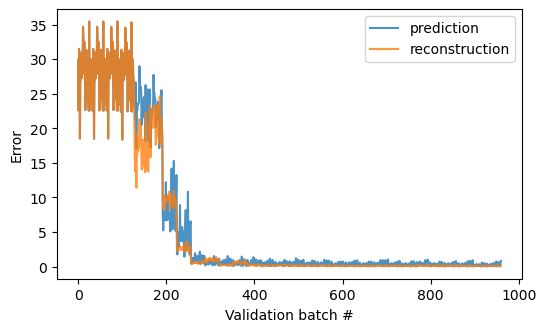

In [4]:
# ---------------------------------------------------------------------------*/
# - training and validation

batch_size = 32

# make validation datasets and loaders
dataset_valid = torch.utils.data.TensorDataset(data_valid)
dataloader_valid = torch.utils.data.DataLoader(dataset_valid, batch_size=batch_size, shuffle=False)

# specify optimizer and a loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# specify the length of our validated prediction
prediction_steps_n = timeseries_len

mse_valid_pred = []
mse_valid_recon = []

datafiles_train_n = 3#random.randint(3, 6)
print(f"inf >> Number of data files for training : {datafiles_train_n}")

for datafile_train in range(datafiles_train_n):
    print(f"inf >> Processing training file number {datafile_train + 1}")
    data_train = utils.read_datafile(f'pendulum_10rad/train{datafile_train + 1}', timeseries_len)

    # make training datasets and loaders
    dataset_train = torch.utils.data.TensorDataset(data_train)
    dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True)

    # train
    for epoch in range(10):

        # train neural networks
        for data in dataloader_train:
            timeseries = data[0] # data are a batch of timeseries

            optimizer.zero_grad()

            loss = model.fit(timeseries)
            loss.backward()

            optimizer.step()

        # validate results
        with torch.no_grad():
            for data in dataloader_valid:
                timeseries = data[0] # data are a batch of timeseries

                # validate prediction
                timeseries_pred = model.predict(timeseries, prediction_steps_n)
                mse_valid_pred.append(torch.mean((timeseries - timeseries_pred)**2))

                # validate reconstruction
                timeseries_recon = model.reconstructor(model.decomposer(timeseries))
                mse_valid_recon.append(torch.mean((timeseries - timeseries_recon)**2))

with torch.no_grad():
    plt.figure(figsize=(6, 3.5))
    plt.plot(mse_valid_pred, alpha=0.8, label='prediction')
    plt.plot(mse_valid_recon, alpha=0.8, label='reconstruction')
    plt.xlabel("Validation batch #")
    plt.ylabel("Error")
    plt.legend()
    plt.show()

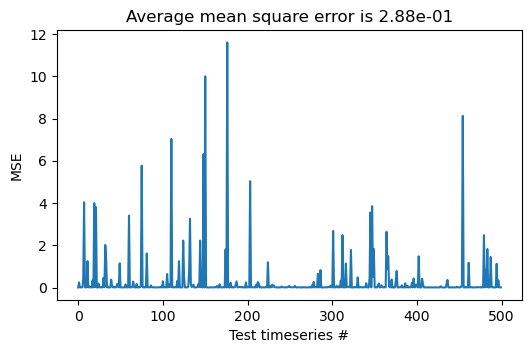

In [5]:
# ---------------------------------------------------------------------------*/
# - test results : check prediction on test data

mse_test_pred = []

for timeseries in data_test:
    timeseries_pred = torch.squeeze(model.predict(torch.unsqueeze(timeseries, dim=0), prediction_steps_n))
    mse_test_pred.append(torch.mean((timeseries - timeseries_pred)**2))

with torch.no_grad():
    avg_mse_test_pred = np.mean(mse_test_pred)

    plt.figure(figsize=(6, 3.5))
    plt.title(f"Average mean square error is {avg_mse_test_pred:.2e}")
    plt.plot(mse_test_pred)
    plt.xlabel("Test timeseries #")
    plt.ylabel("MSE")
    plt.show()

inf >> Eigenvalue ranges from -9.95 to -3.86
inf >> Eigenfunction magnitude ranges from 0.00 to 0.54


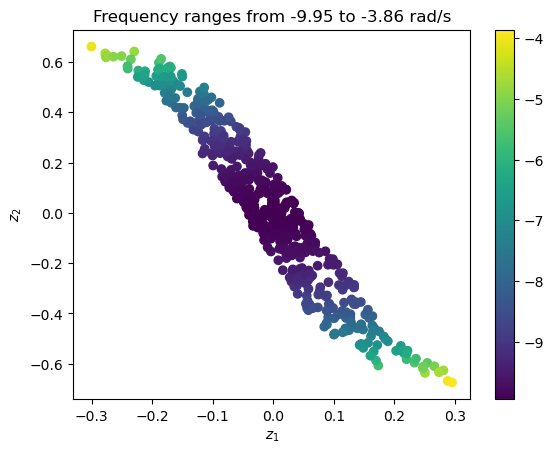

In [6]:
# ---------------------------------------------------------------------------*/
# - test results : check the distribution of frequencies in eigenfunctions

with torch.no_grad():
    eigenfuncs = model.decomposer(model.start_of(data_test))
    eigenvalues = torch.stack([
        model.dynamics(eigenfunc) for eigenfunc in eigenfuncs], dim=0)

    eigenfuncs = torch.reshape(eigenfuncs, (eigenfuncs.shape[0], eigenfuncs.shape[2]))
    eigenvalues = torch.reshape(eigenvalues, (eigenvalues.shape[0], eigenvalues.shape[2]))

    osc_eigenfuncs_n = int(eigenfuncs.shape[1]/osc_n)
    osc_eigenvalues_n = int(eigenvalues.shape[1]/osc_n)

    # split eigenfunctions and eigenvalues per oscillator to facilitate their analysis and displaying
    osc_eigenfuncs = torch.split(eigenfuncs.T, osc_eigenfuncs_n, dim=0)
    osc_eigenvalues = torch.split(eigenvalues.T, osc_eigenvalues_n, dim=0)

    osc_i = range(osc_n)

    for eigenfunc, eigenvalue, i in zip(osc_eigenfuncs, osc_eigenvalues, osc_i):

        eigenvalue_min = torch.min(eigenvalue)
        eigenvalue_max = torch.max(eigenvalue)
        print(f"inf >> Eigenvalue ranges from {eigenvalue_min:.2f} to {eigenvalue_max:.2f}")

        eigenfunc_mag = model.dynamics.constrain_rad(eigenfunc.T)
        eigenfunc_mag_min = torch.min(eigenfunc_mag)
        eigenfunc_mag_max = torch.max(eigenfunc_mag)
        print(f"inf >> Eigenfunction magnitude ranges from {eigenfunc_mag_min:.2f} to {eigenfunc_mag_max:.2f}")

        plt.figure()
        plt.scatter(eigenfunc[0, :], eigenfunc[1, :], c=eigenvalue)
        plt.title(f'Frequency ranges from {eigenvalue_min:.2f} to {eigenvalue_max:.2f} rad/s')
        plt.xlabel('$z_1$')
        plt.ylabel('$z_2$')
        plt.colorbar()
        plt.savefig(f'fig/pendulum/play_dmd_efn_ic_by_freq_{i}.svg')
        plt.show()


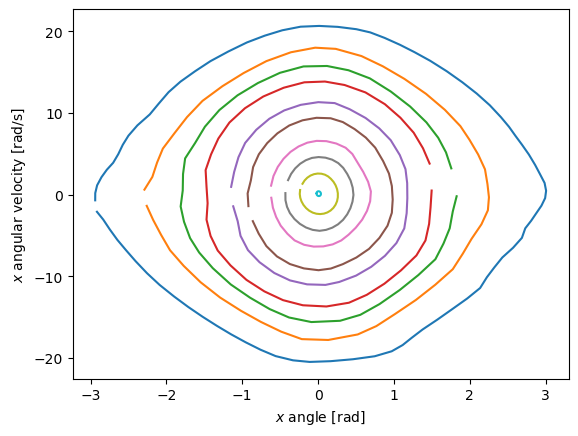

In [7]:
with torch.no_grad():
    # retrieve frequencies for all initial conditions
    eigenvalues = torch.stack(
        [model.dynamics(
            model.decomposer(timeseries[torch.newaxis, 0])) for timeseries in data_test], dim=0)

    eigenvalues = torch.abs(eigenvalues)

    # sort frequencies in ascending order
    eigenvalues, indices = torch.sort(eigenvalues, dim=0)

    # select the indices of n evenly spaced frequencies for plotting
    eigenvalues_j = torch.linspace(0, len(eigenvalues) - 1, 10, dtype=int)

    plt.figure()
    for eigenvalue_j in eigenvalues_j:
        # from angular velocity derive the number of prediction steps for the whole period
        horizon = int(1/(eigenvalues[eigenvalue_j, 0, 0]/(2*torch.pi))/timestep)

        timeseries_i = data_test[indices[eigenvalue_j, 0, 0]]

        # predict the whole period from a given initial condition
        start = torch.unsqueeze(timeseries_i[torch.newaxis, 0], dim=0)
        timeseries_o = model.predict(start, horizon)
        plt.plot(timeseries_o[0, :, 0], timeseries_o[0, :, 1])
    plt.xlabel("$x$ angle [rad]")
    plt.ylabel("$x$ angular velocity [rad/s]")
    plt.savefig(f'fig/pendulum/play_dmd_ts_by_freq.svg')
    plt.show()


In [8]:
# analysis of results

with torch.no_grad():
    data_i = 123
    timeseries = data_test[data_i]
    timeseries = torch.unsqueeze(timeseries, 0)

    eigenfunc = model.decomposer(timeseries)
    eigenfunc = torch.squeeze(eigenfunc, 0)

    eigenvalue = torch.abs(model.dynamics(eigenfunc))
    eigenvalue_mean_0 = torch.mean(eigenvalue[:, 0])
    eigenvalue_mean_1 = torch.mean(eigenvalue[:, 1])
    eigenvalue_0 = eigenvalue[0, 0]
    eigenvalue_1 = eigenvalue[0, 1]
    print(f"inf >> frequency 0 is {eigenvalue_0}")
    print(f"inf >> frequency 1 is {eigenvalue_1}")

    horizon_0 = int(1/(eigenvalue_0/(2*torch.pi))/timestep)
    horizon_1 = int(1/(eigenvalue_1/(2*torch.pi))/timestep)

    horizon = horizon_0

    eigenvalue_pred = eigenvalue[torch.newaxis, 0].expand(horizon, -1)
    eigenfunc_pred = model._impl_predict_from(eigenfunc[torch.newaxis, 0], eigenvalue_pred)

    mag_0 = torch.max(torch.square(eigenfunc[:, 0, torch.newaxis]) + torch.square(eigenfunc[:, 1, torch.newaxis]))
    mag_1 = torch.max(torch.square(eigenfunc[:, 2, torch.newaxis]) + torch.square(eigenfunc[:, 3, torch.newaxis]))
    print(f"inf >> magnitude 0 is {mag_0}")
    print(f"inf >> magnitude 1 is {mag_1}")

    pha_0 = torch.atan2(eigenfunc[:, 0, torch.newaxis], eigenfunc[:, 1, torch.newaxis])
    pha_1 = torch.atan2(eigenfunc[:, 2, torch.newaxis], eigenfunc[:, 3, torch.newaxis])
    print(f"inf >> phase 0 is {torch.max(pha_0)}")
    print(f"inf >> phase 1 is {torch.max(pha_1)}")

    t = torch.linspace(0., horizon_0*timestep, horizon)
    plt.figure()
    plt.plot(t, eigenfunc_pred[:, 0], label=f'f: {eigenvalue_0:.2f} rad/s, a: {mag_0:.2f}')
    plt.plot(t, eigenfunc_pred[:, 2], label=f'f: {eigenvalue_1:.2f} rad/s, a: {mag_1:.2f}')
    plt.xlabel("Time [s]")
    plt.legend()
    plt.savefig(f'fig/pendulum/play_dmd_efn_{data_i}.svg')
    plt.show()

IndexError: index 1 is out of bounds for dimension 1 with size 1

In [ ]:
with torch.no_grad():
    eigenfuncs = model.decomposer(model.start_of(data_test))
    eigenvalues = torch.stack([
        model.dynamics(eigenfunc) for eigenfunc in eigenfuncs], dim=0)

    eigenvalues = torch.abs(eigenvalues)

    # sort frequencies in ascending order
    eigenvalues, indices = torch.sort(eigenvalues, dim=0)

    # select the indices of n evenly spaced frequencies for plotting
    eigenvalues_j = torch.linspace(0, len(eigenvalues) - 1, 10, dtype=int)

    plt.figure()
    for eigenvalue_j in eigenvalues_j:
        # from angular velocity derive the number of prediction steps for the whole period
        horizon = int(1/(eigenvalues[eigenvalue_j, 0, 0]/(2*torch.pi))/timestep)

        eigenfuncs_i = eigenfuncs[indices[eigenvalue_j, 0, 0]]
        start = eigenfuncs_i[torch.newaxis, 0]

        eigenvalue_pred = eigenvalue[torch.newaxis, 0].expand(horizon, -1)
        eigenfunc_pred = model._impl_predict_from(start, eigenvalue_pred)

        plt.plot(eigenfunc_pred[:, 0], eigenfunc_pred[:, 1])
    plt.xlabel("$z_1$")
    plt.ylabel("$z_2$")
    plt.savefig(f'fig/pendulum/play_dmd_efn_by_freq.svg')
    plt.show()